<a href="https://colab.research.google.com/github/saurabhkumar5/Reinforcement_learning/blob/master/RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Q-learning code

import numpy as np
import random

# Grid size
ROWS = 4
COLS = 4

# Actions: 0=up, 1=down, 2=left, 3=right
ACTIONS = [0, 1, 2, 3]
ACTION_NAMES = ["Up", "Down", "Left", "Right"]

# Goal position
GOAL = (3, 3)

# Agent ek action le, new state aur reward mile
def step(state, action):
    row, col = state

    if action == 0:    # up
        row = max(0, row - 1)
    elif action == 1:  # down
        row = min(ROWS - 1, row + 1)
    elif action == 2:  # left
        col = max(0, col - 1)
    elif action == 3:  # right
        col = min(COLS - 1, col + 1)

    new_state = (row, col)

    # Reward
    if new_state == GOAL:
        reward = 10
    else:
        reward = -1  # har step pe penalty taaki jaldi pahunche

    return new_state, reward

print("Environment ready!")

Environment ready!


In [2]:
# Q-Table: har state-action pair ka score
q_table = np.zeros((ROWS, COLS, len(ACTIONS)))

# Hyperparameters
alpha = 0.1      # learning rate
gamma = 0.9      # discount factor
epsilon = 1.0    # exploration rate (pehle random, baad mein smart)
epsilon_decay = 0.995  # har episode mein epsilon kam hoga
epsilon_min = 0.01
episodes = 1000  # kitni baar practice karega

# Training loop
for episode in range(episodes):
    state = (0, 0)  # har baar start se shuru
    done = False
    total_reward = 0

    while not done:
        # Epsilon-Greedy: random action ya best action?
        if random.random() < epsilon:
            action = random.choice(ACTIONS)  # explore (random try)
        else:
            action = np.argmax(q_table[state[0], state[1]])  # exploit (best action)

        # Action lo, result dekho
        new_state, reward = step(state, action)
        total_reward += reward

        # Q-Table update (Q-Learning formula)
        old_q = q_table[state[0], state[1], action]
        max_future_q = np.max(q_table[new_state[0], new_state[1]])
        new_q = old_q + alpha * (reward + gamma * max_future_q - old_q)
        q_table[state[0], state[1], action] = new_q

        state = new_state

        if state == GOAL:
            done = True

    # Epsilon kam karo (explore kam, exploit zyada)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode + 1) % 200 == 0:
        print(f"Episode {episode+1}/{episodes} | Total Reward: {total_reward} | Epsilon: {epsilon:.4f}")

print("\nTraining complete!")

Episode 200/1000 | Total Reward: 2 | Epsilon: 0.3670
Episode 400/1000 | Total Reward: 5 | Epsilon: 0.1347
Episode 600/1000 | Total Reward: 5 | Epsilon: 0.0494
Episode 800/1000 | Total Reward: 5 | Epsilon: 0.0181
Episode 1000/1000 | Total Reward: 5 | Epsilon: 0.0100

Training complete!


In [3]:
# Ab dekhte hain agent ne kya seekha — har state mein konsa action best hai:

# Har state mein best action dikhaao
print("Learned Policy (best action in each state):\n")
for row in range(ROWS):
    for col in range(COLS):
        if (row, col) == GOAL:
            print(" GOAL ", end="")
        else:
            best_action = np.argmax(q_table[row, col])
            print(f" {ACTION_NAMES[best_action]:5}", end="")
    print()

Learned Policy (best action in each state):

 Right Down  Down  Down 
 Down  Down  Down  Down 
 Down  Down  Down  Down 
 Right Right Right GOAL 


In [4]:
# Ab ek aur cheez dekhte hain — Q-Table ke actual values:

print("Q-Values for each state-action:\n")
for row in range(ROWS):
    for col in range(COLS):
        if (row, col) == GOAL:
            print(f"({row},{col}) GOAL")
        else:
            print(f"({row},{col})", end=" | ")
            for a in range(len(ACTIONS)):
                print(f"{ACTION_NAMES[a]}:{q_table[row,col,a]:.2f}", end=" ")
            print()

Q-Values for each state-action:

(0,0) | Up:0.60 Down:1.75 Left:0.59 Right:1.81 
(0,1) | Up:1.77 Down:3.12 Left:0.60 Right:2.83 
(0,2) | Up:-1.04 Down:4.48 Left:0.34 Right:-0.70 
(0,3) | Up:-1.39 Down:2.32 Left:-1.15 Right:-1.12 
(1,0) | Up:-0.23 Down:3.12 Left:0.28 Right:1.25 
(1,1) | Up:1.66 Down:4.58 Left:1.74 Right:4.28 
(1,2) | Up:1.42 Down:6.19 Left:1.73 Right:3.39 
(1,3) | Up:-1.33 Down:7.26 Left:0.41 Right:0.13 
(2,0) | Up:0.49 Down:4.58 Left:2.58 Right:4.32 
(2,1) | Up:3.01 Down:6.20 Left:3.08 Right:6.09 
(2,2) | Up:3.15 Down:8.00 Left:4.08 Right:7.25 
(2,3) | Up:1.79 Down:9.93 Left:3.40 Right:4.13 
(3,0) | Up:2.59 Down:4.27 Left:4.18 Right:6.20 
(3,1) | Up:4.55 Down:6.17 Left:4.57 Right:8.00 
(3,2) | Up:6.15 Down:7.98 Left:6.17 Right:10.00 
(3,3) GOAL


In [8]:
# DQN Code — CartPole Game

# Kya hai CartPole?

# Ek pole (danda) ek cart pe khada hai. Agent ka kaam hai cart ko left/right move karke pole ko girne se bachana. Jitni der pole khada rahe, utna zyada reward. Ye classic RL problem hai.


# !pip install gymnasium torch

import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

# Environment banao
env = gym.make("CartPole-v1")

# Dekho kitne states aur actions hain
print(f"State space: {env.observation_space.shape[0]} values")
print(f"Actions: {env.action_space.n}")

# Ek sample state dekho
state, _ = env.reset()
print(f"Sample state: {state}")

State space: 4 values
Actions: 2
Sample state: [ 0.00981462 -0.0268012  -0.03471282 -0.02519975]


In [9]:
# Ab Neural Network banate hain:

# DQN Neural Network
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)  # har action ka Q-value output

# Settings
state_size = 4
action_size = 2
lr = 0.001
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01
batch_size = 64
memory_size = 10000
target_update = 10  # har 10 episode mein target network update

# Networks
main_network = DQN(state_size, action_size)
target_network = DQN(state_size, action_size)
target_network.load_state_dict(main_network.state_dict())  # copy

optimizer = optim.Adam(main_network.parameters(), lr=lr)
memory = deque(maxlen=memory_size)  # Experience Replay buffer

print("DQN ready!")

DQN ready!


In [10]:
# Ab training functions aur training loop banate hain:

# Experience memory mein store karo
def remember(state, action, reward, next_state, done):
    memory.append((state, action, reward, next_state, done))

# Action choose karo (epsilon-greedy)
def choose_action(state):
    if random.random() < epsilon:
        return random.randrange(action_size)  # explore
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    with torch.no_grad():
        q_values = main_network(state_tensor)
    return q_values.argmax().item()  # exploit

# Experience Replay se seekho
def replay():
    if len(memory) < batch_size:
        return

    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(np.array(states))
    actions = torch.LongTensor(actions)
    rewards = torch.FloatTensor(rewards)
    next_states = torch.FloatTensor(np.array(next_states))
    dones = torch.FloatTensor(dones)

    # Main network se current Q-values
    current_q = main_network(states).gather(1, actions.unsqueeze(1)).squeeze()

    # Target network se future Q-values
    with torch.no_grad():
        max_next_q = target_network(next_states).max(1)[0]
        target_q = rewards + gamma * max_next_q * (1 - dones)

    # Loss calculate karo aur update karo
    loss = nn.MSELoss()(current_q, target_q)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Training
episodes = 300
scores = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0

    for t in range(500):
        action = choose_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        replay()

        if done:
            break

    scores.append(total_reward)

    # Target network update
    if (episode + 1) % target_update == 0:
        target_network.load_state_dict(main_network.state_dict())

    # Epsilon decay
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode + 1) % 50 == 0:
        avg_score = np.mean(scores[-50:])
        print(f"Episode {episode+1} | Avg Score (last 50): {avg_score:.1f} | Epsilon: {epsilon:.4f}")

print("\nTraining complete!")

Episode 50 | Avg Score (last 50): 21.4 | Epsilon: 0.7783
Episode 100 | Avg Score (last 50): 38.6 | Epsilon: 0.6058
Episode 150 | Avg Score (last 50): 91.1 | Epsilon: 0.4715
Episode 200 | Avg Score (last 50): 85.2 | Epsilon: 0.3670
Episode 250 | Avg Score (last 50): 104.4 | Epsilon: 0.2856
Episode 300 | Avg Score (last 50): 87.9 | Epsilon: 0.2223

Training complete!


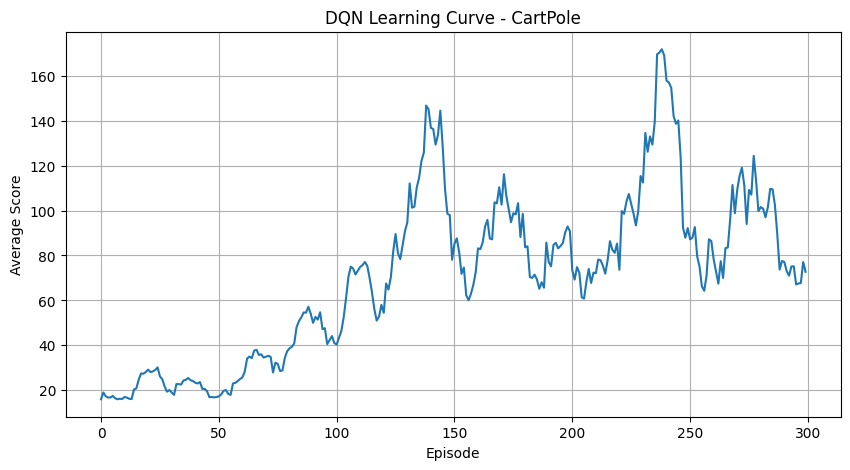

In [11]:
# Ab learning curve dekhte hain visually:

import matplotlib.pyplot as plt

# Har 10 episodes ka average
avg_scores = [np.mean(scores[max(0,i-10):i+1]) for i in range(len(scores))]

plt.figure(figsize=(10, 5))
plt.plot(avg_scores)
plt.xlabel("Episode")
plt.ylabel("Average Score")
plt.title("DQN Learning Curve - CartPole")
plt.grid(True)
plt.show()

In [12]:
# Ab trained agent ko khelke dekhte hain:

# Trained agent test karo
state, _ = env.reset()
total_reward = 0

for t in range(500):
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    with torch.no_grad():
        q_values = main_network(state_tensor)
    action = q_values.argmax().item()

    state, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward

    if terminated or truncated:
        break

print(f"Trained agent score: {total_reward}")
print(f"Pole balanced for {int(total_reward)} steps!")

Trained agent score: 101.0
Pole balanced for 101 steps!


In [13]:
# REINFORCE Code — CartPole

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# Policy Network — state se action probabilities
class PolicyNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.softmax(self.fc2(x), dim=-1)  # probabilities output
        return x

env = gym.make("CartPole-v1")
policy = PolicyNetwork(4, 2)
optimizer = optim.Adam(policy.parameters(), lr=0.01)
gamma = 0.99

print("Policy Network ready!")

Policy Network ready!


In [14]:
# Ab training loop:

scores = []

for episode in range(1000):
    state, _ = env.reset()
    log_probs = []
    rewards = []

    # Step 1: Poora episode khelo
    for t in range(500):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        probs = policy(state_tensor)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()  # probability ke basis pe random action
        log_probs.append(dist.log_prob(action))

        state, reward, terminated, truncated, _ = env.step(action.item())
        rewards.append(reward)

        if terminated or truncated:
            break

    scores.append(sum(rewards))

    # Step 2: Har step ka G_t calculate karo
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)

    returns = torch.FloatTensor(returns)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)  # normalize

    # Step 3: Policy update karo
    loss = 0
    for log_prob, G_t in zip(log_probs, returns):
        loss += -log_prob * G_t  # accha action = probability badhao

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (episode + 1) % 100 == 0:
        avg = np.mean(scores[-100:])
        print(f"Episode {episode+1} | Avg Score (last 100): {avg:.1f}")

print("\nTraining complete!")

Episode 100 | Avg Score (last 100): 68.4
Episode 200 | Avg Score (last 100): 122.1
Episode 300 | Avg Score (last 100): 149.6
Episode 400 | Avg Score (last 100): 175.6
Episode 500 | Avg Score (last 100): 164.0
Episode 600 | Avg Score (last 100): 140.7
Episode 700 | Avg Score (last 100): 181.3
Episode 800 | Avg Score (last 100): 189.4
Episode 900 | Avg Score (last 100): 52.3
Episode 1000 | Avg Score (last 100): 97.7

Training complete!


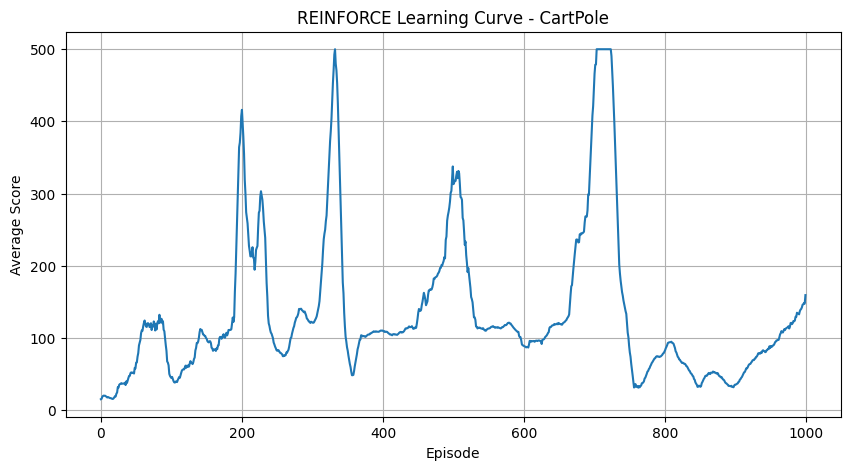

In [15]:
# Ab graph dekhte hain:

import matplotlib.pyplot as plt

avg_scores = [np.mean(scores[max(0,i-10):i+1]) for i in range(len(scores))]

plt.figure(figsize=(10, 5))
plt.plot(avg_scores)
plt.xlabel("Episode")
plt.ylabel("Average Score")
plt.title("REINFORCE Learning Curve - CartPole")
plt.grid(True)
plt.show()

In [16]:
# Actor-Critic Code — CartPole

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# Actor Network — action probabilities
class Actor(nn.Module):
    def __init__(self, state_size, action_size):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return torch.softmax(self.fc2(x), dim=-1)

# Critic Network — state value predict kare
class Critic(nn.Module):
    def __init__(self, state_size):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

env = gym.make("CartPole-v1")
actor = Actor(4, 2)
critic = Critic(4)
actor_optimizer = optim.Adam(actor.parameters(), lr=0.001)
critic_optimizer = optim.Adam(critic.parameters(), lr=0.001)
gamma = 0.99

print("Actor-Critic ready!")

Actor-Critic ready!


In [17]:
# Ab training loop:

scores = []

for episode in range(1000):
    state, _ = env.reset()
    total_reward = 0

    for t in range(500):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)

        # Actor — action choose karo
        probs = actor(state_tensor)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)

        # Step lo
        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated
        total_reward += reward

        next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0)

        # Critic — dono states ki value nikalo
        value = critic(state_tensor)
        next_value = critic(next_state_tensor)

        # Advantage calculate karo
        if done:
            advantage = reward - value
        else:
            advantage = reward + gamma * next_value - value

        # Critic update — better predict karna seekhe
        critic_loss = advantage.pow(2)
        critic_optimizer.zero_grad()
        critic_loss.backward()
        critic_optimizer.step()

        # Actor update — acche actions ki probability badhao
        actor_loss = -log_prob * advantage.detach()
        actor_optimizer.zero_grad()
        actor_loss.backward()
        actor_optimizer.step()

        state = next_state

        if done:
            break

    scores.append(total_reward)

    if (episode + 1) % 100 == 0:
        avg = np.mean(scores[-100:])
        print(f"Episode {episode+1} | Avg Score (last 100): {avg:.1f}")

print("\nTraining complete!")

Episode 100 | Avg Score (last 100): 37.6
Episode 200 | Avg Score (last 100): 69.1
Episode 300 | Avg Score (last 100): 164.2
Episode 400 | Avg Score (last 100): 186.4
Episode 500 | Avg Score (last 100): 164.2
Episode 600 | Avg Score (last 100): 166.8
Episode 700 | Avg Score (last 100): 245.4
Episode 800 | Avg Score (last 100): 197.3
Episode 900 | Avg Score (last 100): 215.1
Episode 1000 | Avg Score (last 100): 299.5

Training complete!


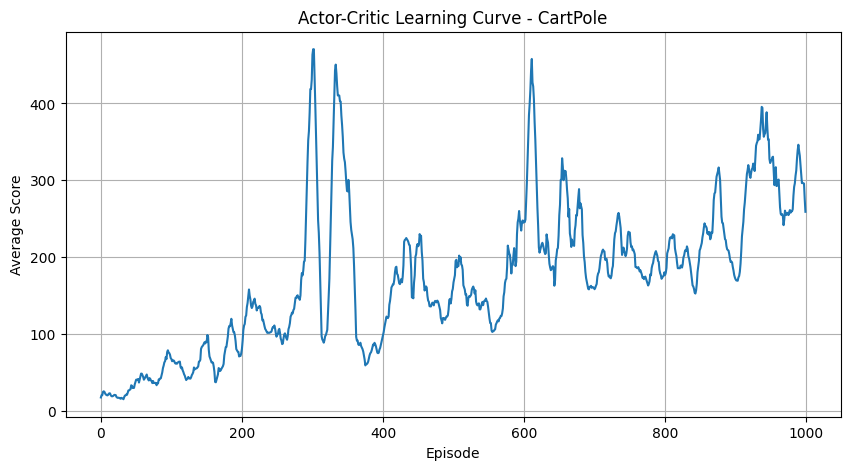

In [18]:
# Ab graph dekhte hain — REINFORCE ke saath compare karenge:

import matplotlib.pyplot as plt

avg_scores = [np.mean(scores[max(0,i-10):i+1]) for i in range(len(scores))]

plt.figure(figsize=(10, 5))
plt.plot(avg_scores)
plt.xlabel("Episode")
plt.ylabel("Average Score")
plt.title("Actor-Critic Learning Curve - CartPole")
plt.grid(True)
plt.show()

In [21]:
# RLHF Code — Simplified Version

# Important: Real RLHF mein bahut bada model chahiye, bahut compute chahiye. Hum ek simplified version banayenge jo concept samjhaye — same steps, chhota scale.

# Scenario: Ek text generator hai jo positive/helpful responses dena seekhega human feedback se.


# !pip install transformers trl datasets torch --quiet


# Step 1: Reward Model ka concept dekhte hain — simplified version:


import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Simple Reward Model — answer ko score de
class RewardModel(nn.Module):
    def __init__(self):
        super(RewardModel, self).__init__()
        self.fc1 = nn.Linear(5, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)  # ek score output

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Fake features representing answer quality
# [length, politeness, helpfulness, accuracy, clarity]
# Human ne label kiya: 1 = good, 0 = bad

training_data = [
    ([0.8, 0.9, 0.9, 0.8, 0.7], 1),  # helpful, polite = good
    ([0.2, 0.1, 0.1, 0.3, 0.2], 0),  # rude, unhelpful = bad
    ([0.7, 0.8, 0.8, 0.9, 0.8], 1),  # accurate, clear = good
    ([0.9, 0.2, 0.3, 0.2, 0.4], 0),  # long but rude = bad
    ([0.5, 0.7, 0.9, 0.8, 0.9], 1),  # concise, helpful = good
    ([0.3, 0.3, 0.2, 0.1, 0.3], 0),  # low quality = bad
    ([0.6, 0.9, 0.7, 0.7, 0.8], 1),  # polite, clear = good
    ([0.8, 0.1, 0.4, 0.5, 0.2], 0),  # rude = bad
]

# Train Reward Model
reward_model = RewardModel()
optimizer = optim.Adam(reward_model.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()

for epoch in range(200):
    total_loss = 0
    for features, label in training_data:
        x = torch.FloatTensor(features)
        y = torch.FloatTensor([label])

        score = reward_model(x)
        loss = loss_fn(score, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1} | Loss: {total_loss/len(training_data):.4f}")

print("\nReward Model trained!")

Epoch 50 | Loss: 0.0001
Epoch 100 | Loss: 0.0000
Epoch 150 | Loss: 0.0000
Epoch 200 | Loss: 0.0000

Reward Model trained!


In [22]:
# Reward Model train ho gaya! Ab test karte hain — naye answers ko score deta hai ya nahi:

# Test Reward Model
test_answers = [
    ([0.7, 0.9, 0.8, 0.9, 0.8], "Polite, helpful, accurate"),
    ([0.9, 0.1, 0.2, 0.3, 0.1], "Long but rude, unhelpful"),
    ([0.5, 0.8, 0.7, 0.8, 0.9], "Concise, polite, clear"),
    ([0.4, 0.2, 0.1, 0.2, 0.3], "Short, rude, wrong"),
]

print("Reward Model Scores:\n")
for features, description in test_answers:
    x = torch.FloatTensor(features)
    with torch.no_grad():
        score = torch.sigmoid(reward_model(x)).item()
    print(f"{description:35} → Score: {score:.4f}")

Reward Model Scores:

Polite, helpful, accurate           → Score: 1.0000
Long but rude, unhelpful            → Score: 0.0000
Concise, polite, clear              → Score: 1.0000
Short, rude, wrong                  → Score: 0.0000


In [27]:
# Ab Step 2: PPO Training — is reward model ke feedback se ek simple policy train karte hain:


class PolicyNet(nn.Module):
    def __init__(self):
        super(PolicyNet, self).__init__()
        self.fc1 = nn.Linear(3, 64)
        self.fc2 = nn.Linear(64, 5)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return torch.sigmoid(self.fc2(x))

for param in reward_model.parameters():
    param.requires_grad = False

policy = PolicyNet()
policy_optimizer = optim.Adam(policy.parameters(), lr=0.001)
feature_names = ["Length", "Polite", "Helpful", "Accurate", "Clear"]

print("PPO Training:\n")

for epoch in range(200):
    context = torch.FloatTensor(np.random.rand(3))
    generated_features = policy(context)
    reward = torch.sigmoid(reward_model(generated_features))
    loss = -reward
    policy_optimizer.zero_grad()
    loss.backward()
    policy_optimizer.step()

    if (epoch + 1) % 50 == 0:
        test_context = torch.FloatTensor([0.5, 0.5, 0.5])
        test_features = policy(test_context)
        test_score = torch.sigmoid(reward_model(test_features)).item()
        print(f"Epoch {epoch+1} | Reward Score: {test_score:.4f}")
        for name, val in zip(feature_names, test_features.detach().tolist()):
            print(f"  {name}: {val:.3f}")
        print()

print("PPO Training complete!")

PPO Training:

Epoch 50 | Reward Score: 0.9956
  Length: 0.342
  Polite: 0.676
  Helpful: 0.604
  Accurate: 0.561
  Clear: 0.566

Epoch 100 | Reward Score: 0.9979
  Length: 0.327
  Polite: 0.692
  Helpful: 0.621
  Accurate: 0.576
  Clear: 0.581

Epoch 150 | Reward Score: 0.9987
  Length: 0.317
  Polite: 0.703
  Helpful: 0.634
  Accurate: 0.586
  Clear: 0.591

Epoch 200 | Reward Score: 0.9992
  Length: 0.308
  Polite: 0.712
  Helpful: 0.646
  Accurate: 0.594
  Clear: 0.600

PPO Training complete!


In [28]:
# RL Project: Snake Game — DQN Agent

# Kya banayenge:

# Snake game jahan AI agent khud seekhega — food khaana, wall se bachna, apne aap se na takrana. DQN use karenge.


# Pehle Snake Game environment banate hain:



import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

class SnakeGame:
    def __init__(self, width=10, height=10):
        self.width = width
        self.height = height
        self.reset()

    def reset(self):
        # Snake start position (beech mein)
        self.snake = [(self.height // 2, self.width // 2)]
        self.direction = 0  # 0=up, 1=right, 2=down, 3=left
        self.food = self._place_food()
        self.score = 0
        self.steps = 0
        self.max_steps = 100
        return self._get_state()

    def _place_food(self):
        while True:
            food = (random.randint(0, self.height - 1), random.randint(0, self.width - 1))
            if food not in self.snake:
                return food

    def _get_state(self):
        head = self.snake[0]
        food = self.food

        # 11 features
        # Danger straight, right, left
        dir_up = self.direction == 0
        dir_right = self.direction == 1
        dir_down = self.direction == 2
        dir_left = self.direction == 3

        # Danger detection
        danger_straight = self._is_danger(
            (head[0] + (-1 if dir_up else 1 if dir_down else 0),
             head[1] + (1 if dir_right else -1 if dir_left else 0)))
        danger_right = self._is_danger(
            (head[0] + (1 if dir_right else -1 if dir_left else 0) if dir_up or dir_down else head[0] + (-1 if dir_right else 1),
             head[1] + (1 if dir_up else -1 if dir_down else 0) if dir_left or dir_right else head[1] + (1 if dir_right else -1)))
        danger_left = self._is_danger(
            (head[0] + (-1 if dir_right else 1 if dir_left else 0) if dir_up or dir_down else head[0] + (1 if dir_right else -1),
             head[1] + (-1 if dir_up else 1 if dir_down else 0) if dir_left or dir_right else head[1] + (-1 if dir_right else 1)))

        state = [
            int(danger_straight),
            int(danger_right),
            int(danger_left),
            int(dir_up),
            int(dir_right),
            int(dir_down),
            int(dir_left),
            int(food[1] < head[1]),  # food left
            int(food[1] > head[1]),  # food right
            int(food[0] < head[0]),  # food up
            int(food[0] > head[0]),  # food down
        ]
        return np.array(state, dtype=np.float32)

    def _is_danger(self, pos):
        return (pos[0] < 0 or pos[0] >= self.height or
                pos[1] < 0 or pos[1] >= self.width or
                pos in self.snake)

    def step(self, action):
        # action: 0=straight, 1=right turn, 2=left turn
        if action == 1:  # right turn
            self.direction = (self.direction + 1) % 4
        elif action == 2:  # left turn
            self.direction = (self.direction - 1) % 4

        head = self.snake[0]
        if self.direction == 0:
            new_head = (head[0] - 1, head[1])
        elif self.direction == 1:
            new_head = (head[0], head[1] + 1)
        elif self.direction == 2:
            new_head = (head[0] + 1, head[1])
        else:
            new_head = (head[0], head[1] - 1)

        self.steps += 1

        # Check collision
        if (new_head[0] < 0 or new_head[0] >= self.height or
            new_head[1] < 0 or new_head[1] >= self.width or
            new_head in self.snake):
            return self._get_state(), -10, True  # died

        self.snake.insert(0, new_head)

        # Check food
        if new_head == self.food:
            self.score += 1
            self.food = self._place_food()
            self.max_steps += 50
            reward = 10
        else:
            self.snake.pop()
            reward = 0

        # Too many steps without food
        if self.steps > self.max_steps:
            return self._get_state(), -10, True

        return self._get_state(), reward, False

# Test
env = SnakeGame()
state = env.reset()
print(f"State size: {len(state)}")
print(f"Sample state: {state}")
print("Environment ready!")

State size: 11
Sample state: [0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0.]
Environment ready!


In [29]:
# Ab DQN Agent banate hain aur train karte hain:

# DQN Network
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(11, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 3)  # 3 actions: straight, right, left

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Agent
class SnakeAgent:
    def __init__(self):
        self.main_net = DQN()
        self.target_net = DQN()
        self.target_net.load_state_dict(self.main_net.state_dict())
        self.optimizer = optim.Adam(self.main_net.parameters(), lr=0.001)
        self.memory = deque(maxlen=100000)
        self.batch_size = 64
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_decay = 0.998
        self.epsilon_min = 0.01

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.randrange(3)
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.main_net(state_tensor)
        return q_values.argmax().item()

    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(actions)
        rewards = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(np.array(next_states))
        dones = torch.FloatTensor(dones)

        current_q = self.main_net(states).gather(1, actions.unsqueeze(1)).squeeze()
        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1)[0]
            target_q = rewards + self.gamma * max_next_q * (1 - dones)

        loss = nn.MSELoss()(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target(self):
        self.target_net.load_state_dict(self.main_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

agent = SnakeAgent()
print("Snake Agent ready!")

Snake Agent ready!


In [30]:
# Ab training loop:

scores = []
best_score = 0

for episode in range(1000):
    state = env.reset()
    total_reward = 0
    score = 0

    while True:
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        agent.remember(state, action, reward, next_state, done)
        agent.replay()
        state = next_state
        total_reward += reward
        score = env.score

        if done:
            break

    scores.append(score)
    agent.decay_epsilon()

    if (episode + 1) % 10 == 0:
        agent.update_target()

    if score > best_score:
        best_score = score

    if (episode + 1) % 100 == 0:
        avg = np.mean(scores[-100:])
        print(f"Episode {episode+1} | Avg Score: {avg:.2f} | Best: {best_score} | Epsilon: {agent.epsilon:.4f}")

print(f"\nTraining complete! Best score: {best_score}")

Episode 100 | Avg Score: 0.35 | Best: 3 | Epsilon: 0.8186
Episode 200 | Avg Score: 0.82 | Best: 4 | Epsilon: 0.6701
Episode 300 | Avg Score: 1.38 | Best: 5 | Epsilon: 0.5485
Episode 400 | Avg Score: 1.96 | Best: 7 | Epsilon: 0.4490
Episode 500 | Avg Score: 2.68 | Best: 11 | Epsilon: 0.3675
Episode 600 | Avg Score: 3.13 | Best: 11 | Epsilon: 0.3008
Episode 700 | Avg Score: 3.98 | Best: 11 | Epsilon: 0.2463
Episode 800 | Avg Score: 4.65 | Best: 16 | Epsilon: 0.2016
Episode 900 | Avg Score: 5.68 | Best: 18 | Epsilon: 0.1650
Episode 1000 | Avg Score: 6.72 | Best: 20 | Epsilon: 0.1351

Training complete! Best score: 20


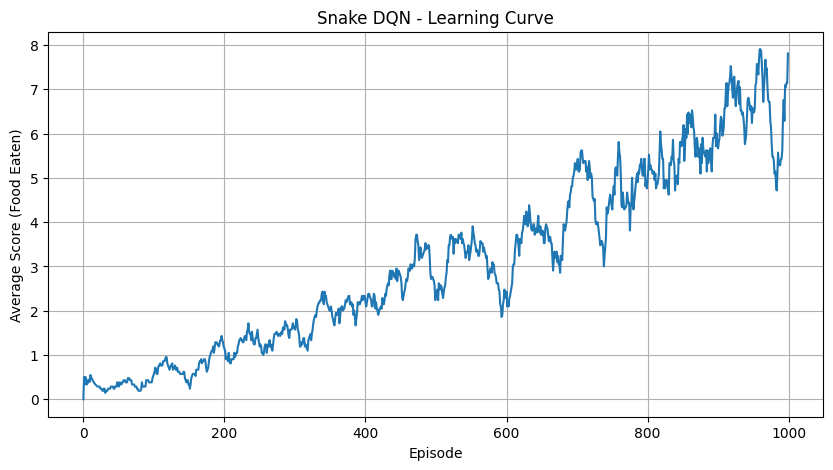


--- Trained Agent Playing ---

Score: 7 food eaten in 64 steps!

Final Board:
+----------+
|..........|
|.....SSSSS|
|.........S|
|.........S|
|.........H|
|..........|
|..........|
|..........|
|..........|
|........F.|
+----------+
H=Head, S=Snake body, F=Food


In [31]:
# Ab learning curve dekhte hain aur phir agent ko khelke dekhte hain visually:

import matplotlib.pyplot as plt

# Learning curve
avg_scores = [np.mean(scores[max(0,i-20):i+1]) for i in range(len(scores))]

plt.figure(figsize=(10, 5))
plt.plot(avg_scores)
plt.xlabel("Episode")
plt.ylabel("Average Score (Food Eaten)")
plt.title("Snake DQN - Learning Curve")
plt.grid(True)
plt.show()

# Agent ko khelke dekho
print("\n--- Trained Agent Playing ---\n")
state = env.reset()
done = False
steps = 0

while not done:
    action = agent.choose_action(state)
    state, reward, done = env.step(action)
    steps += 1

print(f"Score: {env.score} food eaten in {steps} steps!")

# Grid visualize karo
grid = [['.' for _ in range(env.width)] for _ in range(env.height)]
for i, (r, c) in enumerate(env.snake):
    grid[r][c] = 'H' if i == 0 else 'S'
grid[env.food[0]][env.food[1]] = 'F'

print("\nFinal Board:")
print("+" + "-" * env.width + "+")
for row in grid:
    print("|" + "".join(row) + "|")
print("+" + "-" * env.width + "+")
print("H=Head, S=Snake body, F=Food")

KeyboardInterrupt: 

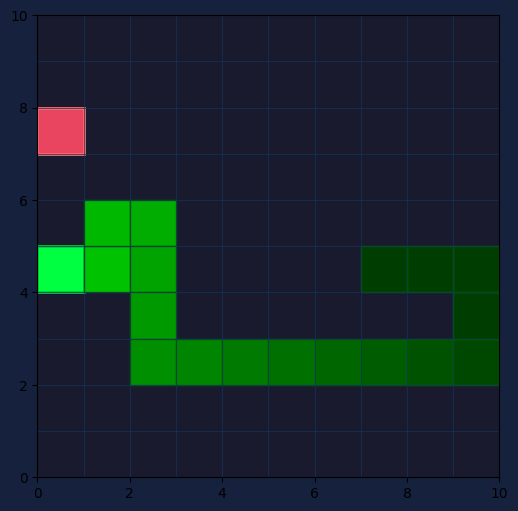

In [32]:
# Visual snake game banate hain jahan real snake dikhega — green snake, red food, sab animated!

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, clear_output
import time

def play_visual_game(agent, env, speed=0.15):
    state = env.reset()
    done = False

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))

    while not done:
        clear_output(wait=True)
        ax.clear()

        # Background
        ax.set_xlim(0, env.width)
        ax.set_ylim(0, env.height)
        ax.set_aspect('equal')
        ax.set_facecolor('#1a1a2e')
        fig.patch.set_facecolor('#16213e')

        # Grid lines
        for i in range(env.width + 1):
            ax.axvline(x=i, color='#0f3460', linewidth=0.5)
        for i in range(env.height + 1):
            ax.axhline(y=i, color='#0f3460', linewidth=0.5)

        # Food (red)
        food_r, food_c = env.food
        ax.add_patch(patches.Rectangle((food_c, env.height - 1 - food_r), 1, 1,
                     facecolor='#e94560', edgecolor='#ff6b6b', linewidth=2))

        # Snake body (green)
        for i, (r, c) in enumerate(env.snake):
            if i == 0:
                # Head (bright green)
                ax.add_patch(patches.Rectangle((c, env.height - 1 - r), 1, 1,
                             facecolor='#00ff41', edgecolor='#00cc33', linewidth=2))
            else:
                # Body (darker green)
                shade = max(0.3, 1 - i * 0.05)
                ax.add_patch(patches.Rectangle((c, env.height - 1 - r), 1, 1,
                             facecolor=(0, shade * 0.8, 0), edgecolor='#006400', linewidth=1))

        ax.set_title(f"Snake AI | Score: {env.score} | Steps: {env.steps}",
                     color='white', fontsize=14, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

        display(fig)
        time.sleep(speed)

        # Agent action
        action = agent.choose_action(state)
        state, reward, done = env.step(action)

    clear_output(wait=True)
    ax.clear()
    ax.set_facecolor('#1a1a2e')
    fig.patch.set_facecolor('#16213e')
    ax.text(0.5, 0.5, f"Game Over!\nScore: {env.score}\nSteps: {env.steps}",
            transform=ax.transAxes, ha='center', va='center',
            fontsize=20, color='#e94560', fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
    display(fig)
    plt.close()

# Agent ka epsilon kam karo taaki best moves kare
old_epsilon = agent.epsilon
agent.epsilon = 0.01

play_visual_game(agent, SnakeGame(), speed=0.15)

agent.epsilon = old_epsilon

In [33]:
# Colab ki limitation hai — clear_output se flickering hoti hai. Better approach — pehle saara game record karo, phir smooth animation banao:


import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from IPython.display import HTML

def record_game(agent, env):
    state = env.reset()
    done = False
    frames = []

    while not done:
        # Current frame save karo
        frame = {
            'snake': list(env.snake),
            'food': env.food,
            'score': env.score,
            'steps': env.steps
        }
        frames.append(frame)

        action = agent.choose_action(state)
        state, reward, done = env.step(action)

    # Last frame
    frames.append({
        'snake': list(env.snake),
        'food': env.food,
        'score': env.score,
        'steps': env.steps
    })
    return frames

def animate_game(frames, env):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))

    def draw_frame(i):
        ax.clear()
        frame = frames[i]

        ax.set_xlim(0, env.width)
        ax.set_ylim(0, env.height)
        ax.set_aspect('equal')
        ax.set_facecolor('#1a1a2e')
        fig.patch.set_facecolor('#16213e')

        for x in range(env.width + 1):
            ax.axvline(x=x, color='#0f3460', linewidth=0.5)
        for y in range(env.height + 1):
            ax.axhline(y=y, color='#0f3460', linewidth=0.5)

        # Food
        food_r, food_c = frame['food']
        ax.add_patch(patches.Rectangle((food_c, env.height - 1 - food_r), 1, 1,
                     facecolor='#e94560', edgecolor='#ff6b6b', linewidth=2))

        # Snake
        for i, (r, c) in enumerate(frame['snake']):
            if i == 0:
                ax.add_patch(patches.Rectangle((c, env.height - 1 - r), 1, 1,
                             facecolor='#00ff41', edgecolor='#00cc33', linewidth=2))
            else:
                shade = max(0.3, 1 - i * 0.05)
                ax.add_patch(patches.Rectangle((c, env.height - 1 - r), 1, 1,
                             facecolor=(0, shade * 0.8, 0), edgecolor='#006400', linewidth=1))

        ax.set_title(f"Snake AI | Score: {frame['score']} | Steps: {frame['steps']}",
                     color='white', fontsize=14, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

    anim = animation.FuncAnimation(fig, draw_frame, frames=len(frames), interval=150, repeat=False)
    plt.close()
    return anim

# Game record karo aur animate karo
old_epsilon = agent.epsilon
agent.epsilon = 0.01

frames = record_game(agent, SnakeGame())
anim = animate_game(frames, SnakeGame())

agent.epsilon = old_epsilon

HTML(anim.to_jshtml())